<a href="https://colab.research.google.com/github/lauragragera/Procesos-Estocasticos/blob/main/PAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from matplotlib import pyplot as plt

## Implementación de una función para dibujar el PAS

In [9]:
def simular_PAS(p,n,reps=1):
  # Input:
  # p: Es la probabilidad de que la variable aleatoria Z_s tome el valor 1
  # (moverse hacia arriba). La probabilidad de tomar el valor -1 (moverse hacia
  # abajo) es 1-p.
  # n: Instante t=n del conjunto de índices discreto T=N. Determina la longitud
  # temporal de la simulación. Número natural
  # reps: Número de trayectorias del PE a generar. Cada trayectoria es una
  # posible realización del PE a lo largo del tiempo. Número natural

  # Output:
  # output: Array que contiene las trayectorias del PAS. Para cada trayectoria,
  # almacena el valor de X_t (la posición en el instante t, que es la suma de
  # los movimientos Z_s).

  # Generamos la matriz de los movimientos Z_s
  # Z_s toma valores en {1, -1} con probabilidades p y 1-p respectivamente
  Z_s = np.random.choice([1, -1], (reps, n), replace = True, p=[p,1-p])
  # Shape esperado: (reps, n)

  # Calculamos las trayectorias X_t como la suma acumulada de Z_s
  # Aplicamos la definición formal del PAS: X_t = Sum(Z_s) desde s=1 hasta t
  # Usamos axis=1 para que la suma acumulada se haga a lo largo del tiempo
  # (columnas) para cada trayectoria (filas) de forma independiente.
  output = np.cumsum(Z_s, axis = 1)
  # Shape esperado: (reps, n)

  return output  # Shape: (reps, n)

### Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)

p = 0.5

Text(0, 0.5, '$X_t$')

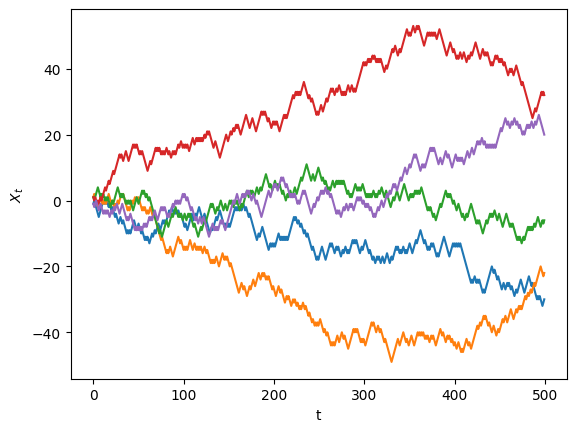

In [14]:
plt.plot(simular_PAS(p=0.5, n=500, reps=5).T)
# Transponemos la matriz con .T porque plt.plot dibuja cada columna como una
# línea.Así conseguimos 5 líneas de 500 pasos en lugar de 500 líneas de 5
# pasos.
plt.xlabel('t')
plt.ylabel('$X_t$')
# Nombramos los ejes


p = 0.6

Text(0, 0.5, '$X_t$')

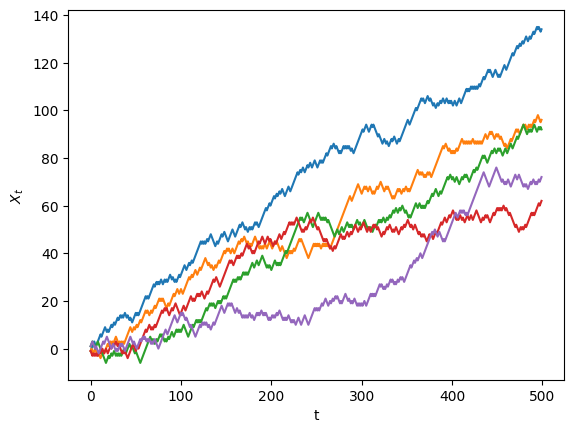

In [16]:
plt.plot(simular_PAS(p=0.6, n=500, reps=5).T)
plt.xlabel('t')
plt.ylabel('$X_t$')

p = 0.4

Text(0, 0.5, '$X_t$')

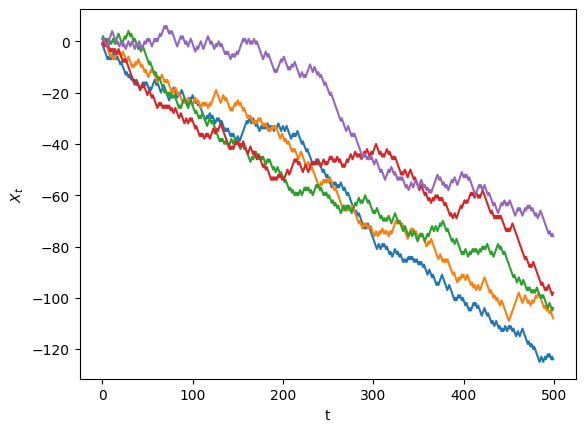

In [17]:
plt.plot(simular_PAS(p=0.4, n=500, reps=5).T)
plt.xlabel('t')
plt.ylabel('$X_t$')

### Visualización 2: diferentes trayectorias del PAS (con media y desviación típica teóricas)

p = 0.5

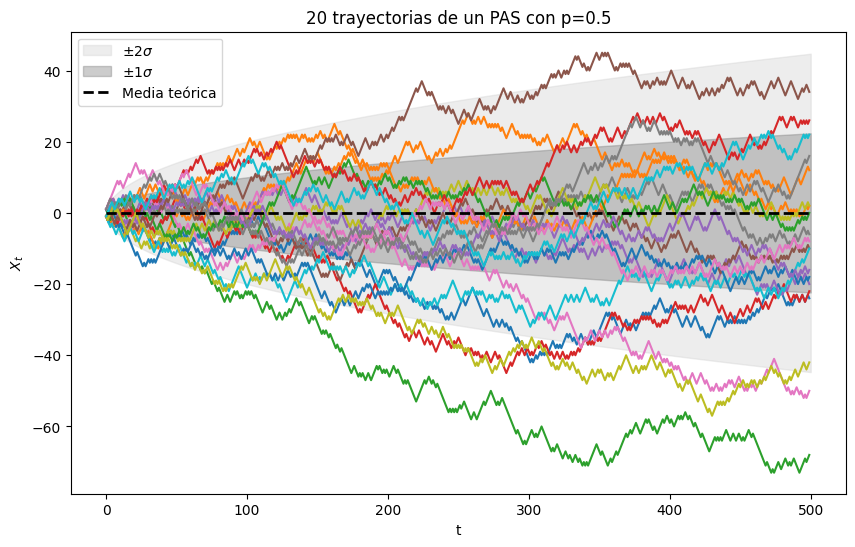

In [31]:
n = 500
p = 0.5

# t: Vector de tiempo que representa el conjunto de índices T=N. Contiene los
# instantes desde t=0 hasta t=n. Servirá como eje horizontal (X) para la gráfica
t = np.arange(n + 1)
# Shape esperado: (501,)

# media_teorica: Array que contiene la función de medias del PAS en cada
# instante t. Se calcula analíticamente como E[X_t] = (2p - 1)*t.
media_teorica = (2 * p - 1) * t
# Shape esperado: (501,)

# std_teorica: Array que contiene la desviación típica teórica en cada instante
# t.Se calcula como la raíz cuadrada de la varianza: sqrt(4*t*p*(1-p)).
std_teorica = np.sqrt(4 * t * p * (1 - p))
# Shape esperado: (501,)

plt.figure(figsize=(10, 6))

# Sombreado de +- 2 veces la desviación típica
plt.fill_between(t, media_teorica - 2*std_teorica, media_teorica +
                 2*std_teorica, color='lightgray', alpha=0.4, label=r'±2$\sigma$')

# Sombreado de +- 1 veces la desviación típica (gris un poco más oscuro)
plt.fill_between(t, media_teorica - std_teorica, media_teorica + std_teorica,
                 color='gray', alpha=0.4, label=r'±1$\sigma$')

plt.plot(simular_PAS(p=0.5, n=500, reps=20).T)
plt.title(f'20 trayectorias de un PAS con p={p}')
plt.xlabel('t')
plt.ylabel('$X_t$')

# Dibujamos la media teórica encima de todo
plt.plot(t, media_teorica, color='black', linestyle='--', linewidth=2,
         label='Media teórica')

# Leyenda
plt.legend(loc='upper left')

p = 0.75

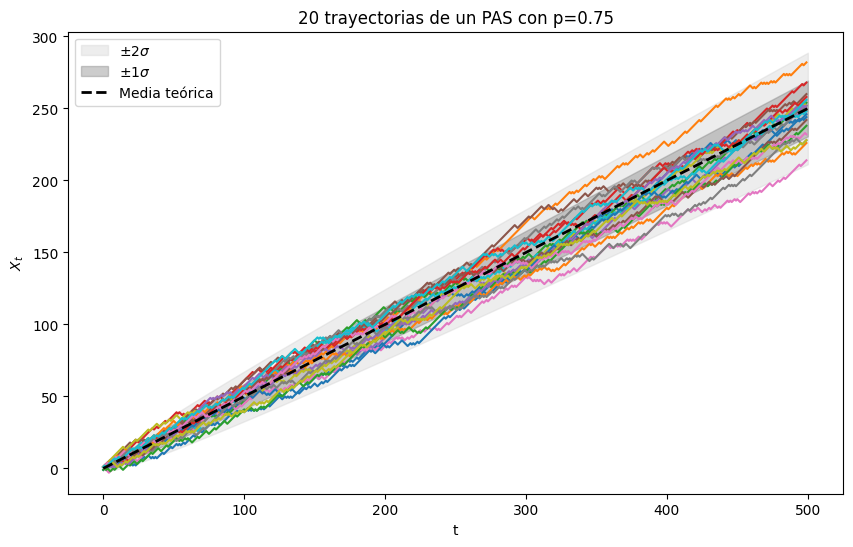

In [33]:
n = 500
p = 0.75
t = np.arange(n + 1)

media_teorica = (2 * p - 1) * t
std_teorica = np.sqrt(4 * t * p * (1 - p))

plt.figure(figsize=(10, 6))

plt.fill_between(t, media_teorica - 2*std_teorica, media_teorica +
                 2*std_teorica, color='lightgray', alpha=0.4, label=r'±2$\sigma$')

plt.fill_between(t, media_teorica - std_teorica, media_teorica + std_teorica,
                 color='gray', alpha=0.4, label=r'±1$\sigma$')

plt.plot(simular_PAS(p=0.75, n=500, reps=20).T)
plt.title(f'20 trayectorias de un PAS con p={p}')
plt.xlabel('t')
plt.ylabel('$X_t$')
plt.plot(t, media_teorica, color='black', linestyle='--', linewidth=2,
         label='Media teórica')
plt.legend(loc='upper left')

p = 0.95

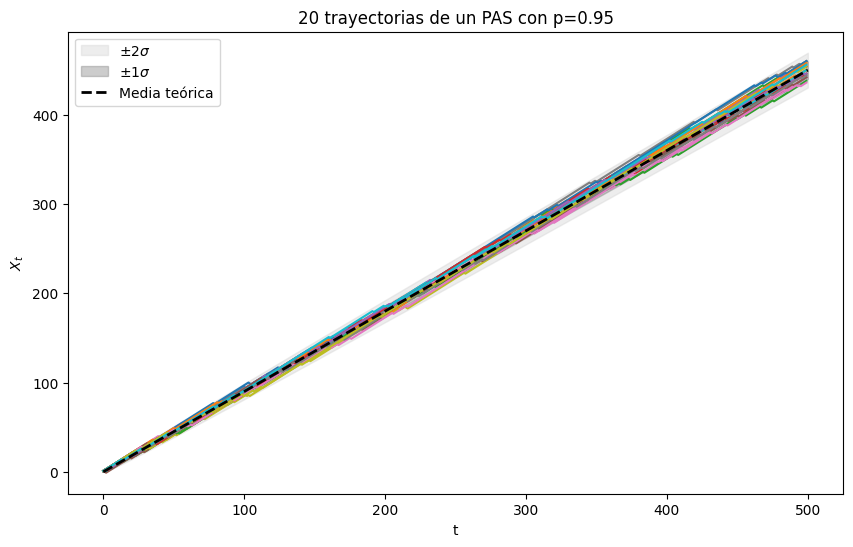

In [34]:
n = 500
p = 0.95
t = np.arange(n + 1)

media_teorica = (2 * p - 1) * t
std_teorica = np.sqrt(4 * t * p * (1 - p))

plt.figure(figsize=(10, 6))

plt.fill_between(t, media_teorica - 2*std_teorica, media_teorica +
                 2*std_teorica, color='lightgray', alpha=0.4, label=r'±2$\sigma$')

plt.fill_between(t, media_teorica - std_teorica, media_teorica + std_teorica,
                 color='gray', alpha=0.4, label=r'±1$\sigma$')

plt.plot(simular_PAS(p=0.95, n=500, reps=20).T)
plt.title(f'20 trayectorias de un PAS con p={p}')
plt.xlabel('t')
plt.ylabel('$X_t$')
plt.plot(t, media_teorica, color='black', linestyle='--', linewidth=2,
         label='Media teórica')
plt.legend(loc='upper left')

### Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica)

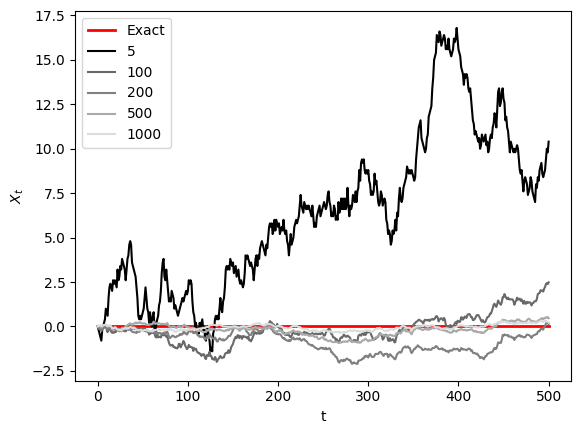

In [48]:
n = 500
p = 0.5

# Vector de tiempo y media teórica como en la visualización anterior
t = np.arange(n + 1)
media_teorica = (2 * p - 1) * t

# Generamos las 1000 trayectorias
trayectorias_bruto = simular_PAS(p, n, 1000)
# Shape: (1000, 500)

# Le pegamos la columna de ceros al principio para conseguir el tamaño
# del array que necesitamos
trayectorias = np.hstack((np.zeros((1000, 1)), trayectorias_bruto))
# Shape: (1000, 501)

# Cálculo vectorial de medias acumuladas, suma las trayectorias una sobre otra.
sumas = np.cumsum(trayectorias, axis=0)
# Shape: (1000, 501)

# Creamos un divisor: un vector de índices para poder dividir cada fila por el
# número de trayectorias que contiene.
divisores = np.arange(1, 1001).reshape(-1, 1)
# Shape: (1000, 1)

# Obtenemos la matriz de todas las medias posibles de golpe.
# La fila i de esta matriz es la media de las primeras i+1 trayectorias.
medias = sumas / divisores
# Shape: (1000, 501)

# Representamos la media teórica
plt.plot(t, media_teorica, color='red', linewidth=2, label='Exact')

# Dibujamos las filas que nos interesan (5, 100, 200, 500, 1000)
# (Restamos 1 porque los índices empiezan en 0)
plt.plot(t, medias[4], color='black', label='5')
plt.plot(t, medias[99], color='dimgray', label='100')
plt.plot(t, medias[199], color='gray', label='200')
plt.plot(t, medias[499], color='darkgray', label='500')
plt.plot(t, medias[999], color='gainsboro', label='1000')

plt.xlabel('t')
plt.ylabel('$X_t$')

plt.legend(loc='upper left')